# EOG Symmetry Detection from Raw EDF Signals - Version 2

This version loads raw EDF signals directly without normalization.
- Loads EDF files directly using modules from sleep_stage
- Processes raw EOG signals without normalization
- Uses original file's start time (base_time) instead of first onset from SLEEP XML
- Generates XML output with symmetric EOG events

In [12]:
import sys
import os
sys.path.append('/home/honeynaps/data/shared/integrate/sleep_stage')

import random
import torch
import torch.nn as nn
import numpy as np
import pickle
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import timedelta, datetime
import datetime as dt

# Import sleep_stage modules
from sleep_stage.modules.iofiles import edf as edf_io
from sleep_stage.modules.preprocessing import prep_psg_signal, prep_psg_signal_with_missing
from sleep_stage.prep_window_wise import epoching_from_time
from sleep_stage.utils.tools import str2bool

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(5)
np.random.seed(5)
random.seed(5)

In [13]:
def load_edf_raw(edf_path, fs=50):
    """
    Load EDF file and extract raw signals without normalization
    Based on sleep_score.py and SleepFinal.py
    
    Args:
        edf_path: Path to EDF file
        fs: Sampling frequency (default: 50Hz)
    
    Returns:
        sigs: Dictionary of signals
        base_time: Recording start time
        X: Epoched data (n_epochs, n_samples, n_channels)
        ch_names: Channel names
    """
    # Load EDF using edf_io module
    edf, n_missing_ch = edf_io.load(
        path       = edf_path, 
        preload    = True, 
        resample   = fs, 
        preset     = "STAGENET", 
        exclude    = True,
        missing_ch = 'raise'
    )
    
    base_time = edf.info['meas_date'].replace(tzinfo=None)
    data = edf.get_data()
    
    # Channel mapping (from sleep_score.py)
    SID_MAP = { 
        'F3-':'F3_2', 'F4-':'F4_1', 'C3-':'C3_2', 'C4-':'C4_1', 
        'O1-':'O1_2', 'O2-':'O2_1', 
        'LOC':'LOC' , 'ROC':'ROC', 
        'EMG':'CHIN'
    }
    
    sigs = {}
    for i in range(len(edf.ch_names)):
        name = edf.ch_names[i]
        if name in SID_MAP:
            sigs[SID_MAP[name]] = data[i]
        else:
            sigs[SID_MAP[name[:3]]] = data[i]
    
    # Channel sequence (from SleepFinal.py)
    SID_SEQs = ['F3_2', 'F4_1', 'C3_2', 'C4_1', 'O1_2', 'O2_1', 'LOC', 'ROC', 'CHIN']
    ordered_data = [None for _ in range(len(SID_SEQs))]
    
    for sid, sig in sigs.items():
        if sid in SID_SEQs:
            i = SID_SEQs.index(sid)
            ordered_data[i] = sig
    
    # Check for missing channels
    missing_channels = [i for i in range(9) if ordered_data[i] is None]
    ordered_data = [d for d in ordered_data if d is not None]
    ordered_data = np.array(ordered_data)
    
    # Epoch the data (raw, without preprocessing)
    X = epoching_from_time(ordered_data.T, base_time, base_time, sfreq=fs)
    
    return sigs, base_time, X, edf.ch_names

In [14]:
def calculate_eog_symmetry(loc_signal, roc_signal, window_size=50, stride=25):
    """
    Calculate EOG symmetry based on correlation and amplitude ratio
    
    Args:
        loc_signal: Left EOG signal (1500 samples for 30 seconds at 50Hz)
        roc_signal: Right EOG signal (1500 samples for 30 seconds at 50Hz)
        window_size: Size of sliding window (samples)
        stride: Stride for sliding window (samples)
    
    Returns:
        symmetry_scores: Array of symmetry scores for each window
        window_positions: Start positions of each window
    """
    symmetry_scores = []
    window_positions = []
    
    for i in range(0, len(loc_signal) - window_size + 1, stride):
        loc_window = loc_signal[i:i+window_size]
        roc_window = roc_signal[i:i+window_size]
        
        # Calculate correlation
        if np.std(loc_window) > 0 and np.std(roc_window) > 0:
            correlation = np.corrcoef(loc_window, roc_window)[0, 1]
        else:
            correlation = 0
        
        # Calculate amplitude ratio
        loc_amp = np.sqrt(np.mean(loc_window**2))
        roc_amp = np.sqrt(np.mean(roc_window**2))
        
        if loc_amp > 0 and roc_amp > 0:
            amp_ratio = min(loc_amp, roc_amp) / max(loc_amp, roc_amp)
        else:
            amp_ratio = 0
        
        # Combined symmetry score
        symmetry = correlation * amp_ratio
        
        symmetry_scores.append(symmetry)
        window_positions.append(i)
    
    return np.array(symmetry_scores), np.array(window_positions)

In [15]:
def save_symmetric_eog_xml(base_time, y_all_epochs, sfreq, xml_save_path, 
                           description="EOG_SYMMETRIC", location="EOG", min_duration=0.5):
    """
    Save symmetric EOG events to XML file using base_time from EDF
    """
    # Find continuous periods of symmetric EOG
    diff_y = np.diff(np.concatenate([[0], y_all_epochs, [0]]))  
    start_points = np.where(diff_y == 1)[0]
    end_points = np.where(diff_y == -1)[0]

    root = ET.Element("annotationlist")
    
    # Add recording duration (no recording_start_time)
    recording_duration = len(y_all_epochs) / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"

    event_count = 0
    for start_idx, end_idx in zip(start_points, end_points):
        start_sec = start_idx / sfreq
        end_sec = end_idx / sfreq
        duration = end_sec - start_sec

        # Only include events longer than minimum duration
        if duration < min_duration:
            continue

        # Calculate onset time using base_time from EDF
        onset_time = base_time + timedelta(seconds=start_sec)

        annotation = ET.SubElement(root, "annotation")

        onset_elem = ET.SubElement(annotation, "onset")
        onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")

        duration_elem = ET.SubElement(annotation, "duration")
        duration_elem.text = f"{duration:.6f}"

        desc_elem = ET.SubElement(annotation, "description")
        desc_elem.text = description

        location_elem = ET.SubElement(annotation, "location")
        location_elem.text = location
        
        event_count += 1

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)

    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count

In [16]:
def load_sleep_stage_xml(xml_path):
    """
    Load sleep stage XML and return labels (for reference only, not used for timing)
    
    Args:
        xml_path: Path to the SLEEP XML file
    
    Returns:
        sleep_stages: List of sleep stage labels
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        sleep_stages = []
        
        # Parse all annotations to get sleep stages
        for annotation in root.findall("annotation"):
            description = annotation.find("description").text
            # Convert stage description to numeric label
            if 'W' in description:
                sleep_stages.append(0)
            elif "R" in description:
                sleep_stages.append(1)
            elif "1" in description:
                sleep_stages.append(2)
            elif "2" in description:
                sleep_stages.append(3)
            elif "3" in description:
                sleep_stages.append(4)
        
        return sleep_stages
    except Exception as e:
        print(f"Error reading SLEEP XML {xml_path}: {e}")
        return []

In [17]:
# Configuration
fs = 50
loc_channel_idx = 6  # LOC is the 7th channel (0-indexed)
roc_channel_idx = 7  # ROC is the 8th channel (0-indexed)
window_size = 50     # 1 second window at 50Hz
stride = 25          # 0.5 second stride

# Data paths
edf_dir = '/home/honeynaps/data/GOLDEN/EDF2'
sleep_xml_dir = '/home/honeynaps/data/GOLDEN/EBX2/SLEEP'
output_dir = '/home/honeynaps/data/shared/integrate/output'

# Get list of EDF files
edf_files = natsort.natsorted([f for f in os.listdir(edf_dir) if f.endswith('.edf')])
print(f"Found {len(edf_files)} EDF files")

# Process first 5 files
max_files = 5
edf_files = edf_files[:max_files]
print(f"Processing {len(edf_files)} files")

Found 16 EDF files
Processing 5 files


In [18]:
# Load data and extract EOG signals
all_eog_data = []
all_symmetry_scores = []
all_sleep_stages = []
rem_symmetry_scores = []
file_data_mapping = []
sleep_stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

print("Loading EDF files and calculating EOG symmetry...")

for file_idx, edf_file in enumerate(edf_files):
    print(f"\nProcessing file {file_idx + 1}/{len(edf_files)}: {edf_file}")
    
    edf_path = os.path.join(edf_dir, edf_file)
    base_name = edf_file.replace('.edf', '')
    
    # Load corresponding SLEEP XML to get sleep stages (for statistics only)
    sleep_xml_path = os.path.join(sleep_xml_dir, f"{base_name}_SLEEP.xml")
    
    if not os.path.exists(sleep_xml_path):
        print(f"  Warning: SLEEP XML not found: {sleep_xml_path}")
        continue
    
    # Load sleep stages from XML (for reference)
    sleep_stages = load_sleep_stage_xml(sleep_xml_path)
    
    if len(sleep_stages) == 0:
        print(f"  Error loading SLEEP XML")
        continue
    
    # Load raw EDF data
    try:
        sigs, base_time, X, ch_names = load_edf_raw(edf_path, fs=fs)
        print(f"  Loaded EDF: {X.shape[0]} epochs, {X.shape[1]} samples, {X.shape[2]} channels")
        print(f"  Base time (EDF start): {base_time}")
    except Exception as e:
        print(f"  Error loading EDF: {e}")
        continue
    
    # Process each epoch
    n_epochs = min(X.shape[0], len(sleep_stages))
    print(f"  Processing {n_epochs} epochs")
    
    for epoch_idx in range(n_epochs):
        # Extract EOG signals (channels 6 and 7)
        loc_signal = X[epoch_idx, :, loc_channel_idx]
        roc_signal = X[epoch_idx, :, roc_channel_idx]
        
        # Scale signals (raw values)
        loc_signal *= 1000
        roc_signal *= 1000
        
        sleep_stage = sleep_stages[epoch_idx]
        
        # Calculate symmetry scores
        symmetry_scores, window_positions = calculate_eog_symmetry(
            loc_signal, roc_signal, window_size, stride
        )
        
        all_eog_data.append((loc_signal, roc_signal))
        all_symmetry_scores.extend(symmetry_scores)
        all_sleep_stages.extend([sleep_stage] * len(symmetry_scores))
        file_data_mapping.append({
            'file_idx': file_idx, 
            'file_name': edf_file, 
            'base_name': base_name,
            'base_time': base_time,  # Using base_time from EDF
            'local_epoch_idx': epoch_idx
        })
        
        # Collect REM symmetry scores for threshold calculation
        if sleep_stage == 1:  # REM stage
            rem_symmetry_scores.extend(symmetry_scores)

all_symmetry_scores = np.array(all_symmetry_scores)
all_sleep_stages = np.array(all_sleep_stages)
rem_symmetry_scores = np.array(rem_symmetry_scores)

print(f"\nTotal epochs processed: {len(all_eog_data)}")
print(f"Total symmetry windows: {len(all_symmetry_scores)}")
print(f"REM windows for threshold calculation: {len(rem_symmetry_scores)}")

Loading EDF files and calculating EOG symmetry...

Processing file 1/5: SCH-230114R3_M-60-OV-SE.edf
  Loaded EDF: 784 epochs, 1500 samples, 9 channels
  Base time (EDF start): 2023-01-14 20:58:49
  Processing 779 epochs

Processing file 2/5: SCH_F_20_OB_231128R4_NO.edf
  Loaded EDF: 920 epochs, 1500 samples, 9 channels
  Base time (EDF start): 2023-11-28 22:11:30
  Processing 894 epochs

Processing file 3/5: SCH_F_20_OV_230715R3_MO.edf
  Loaded EDF: 898 epochs, 1500 samples, 9 channels
  Base time (EDF start): 2023-07-15 22:12:17
  Processing 890 epochs

Processing file 4/5: SCH_F_40_NW_230511R3_SE.edf
  Loaded EDF: 834 epochs, 1500 samples, 9 channels
  Base time (EDF start): 2023-05-11 22:34:32
  Processing 824 epochs

Processing file 5/5: SCH_F_40_NW_231130R4_MO.edf
  Loaded EDF: 848 epochs, 1500 samples, 9 channels
  Base time (EDF start): 2023-11-30 22:05:57
  Processing 836 epochs

Total epochs processed: 4223
Total symmetry windows: 249157
REM windows for threshold calculation: 

In [19]:
# Calculate threshold based on REM statistics
threshold_percentile = 50  # Use median

if len(rem_symmetry_scores) > 0:
    threshold = np.percentile(rem_symmetry_scores, threshold_percentile)
else:
    threshold = 0.5  # Default threshold if no REM data

print(f"Symmetric EOG threshold: {threshold:.4f} (using {threshold_percentile}th percentile)")

# Basic statistics
if len(rem_symmetry_scores) > 0:
    print(f"\nREM symmetry statistics:")
    print(f"  Mean: {np.mean(rem_symmetry_scores):.4f}")
    print(f"  Std: {np.std(rem_symmetry_scores):.4f}")
    print(f"  25th percentile: {np.percentile(rem_symmetry_scores, 25):.4f}")
    print(f"  50th percentile: {np.percentile(rem_symmetry_scores, 50):.4f}")
    print(f"  75th percentile: {np.percentile(rem_symmetry_scores, 75):.4f}")

Symmetric EOG threshold: 0.1542 (using 50th percentile)

REM symmetry statistics:
  Mean: 0.0600
  Std: 0.4703
  25th percentile: -0.3276
  50th percentile: 0.1542
  75th percentile: 0.4389


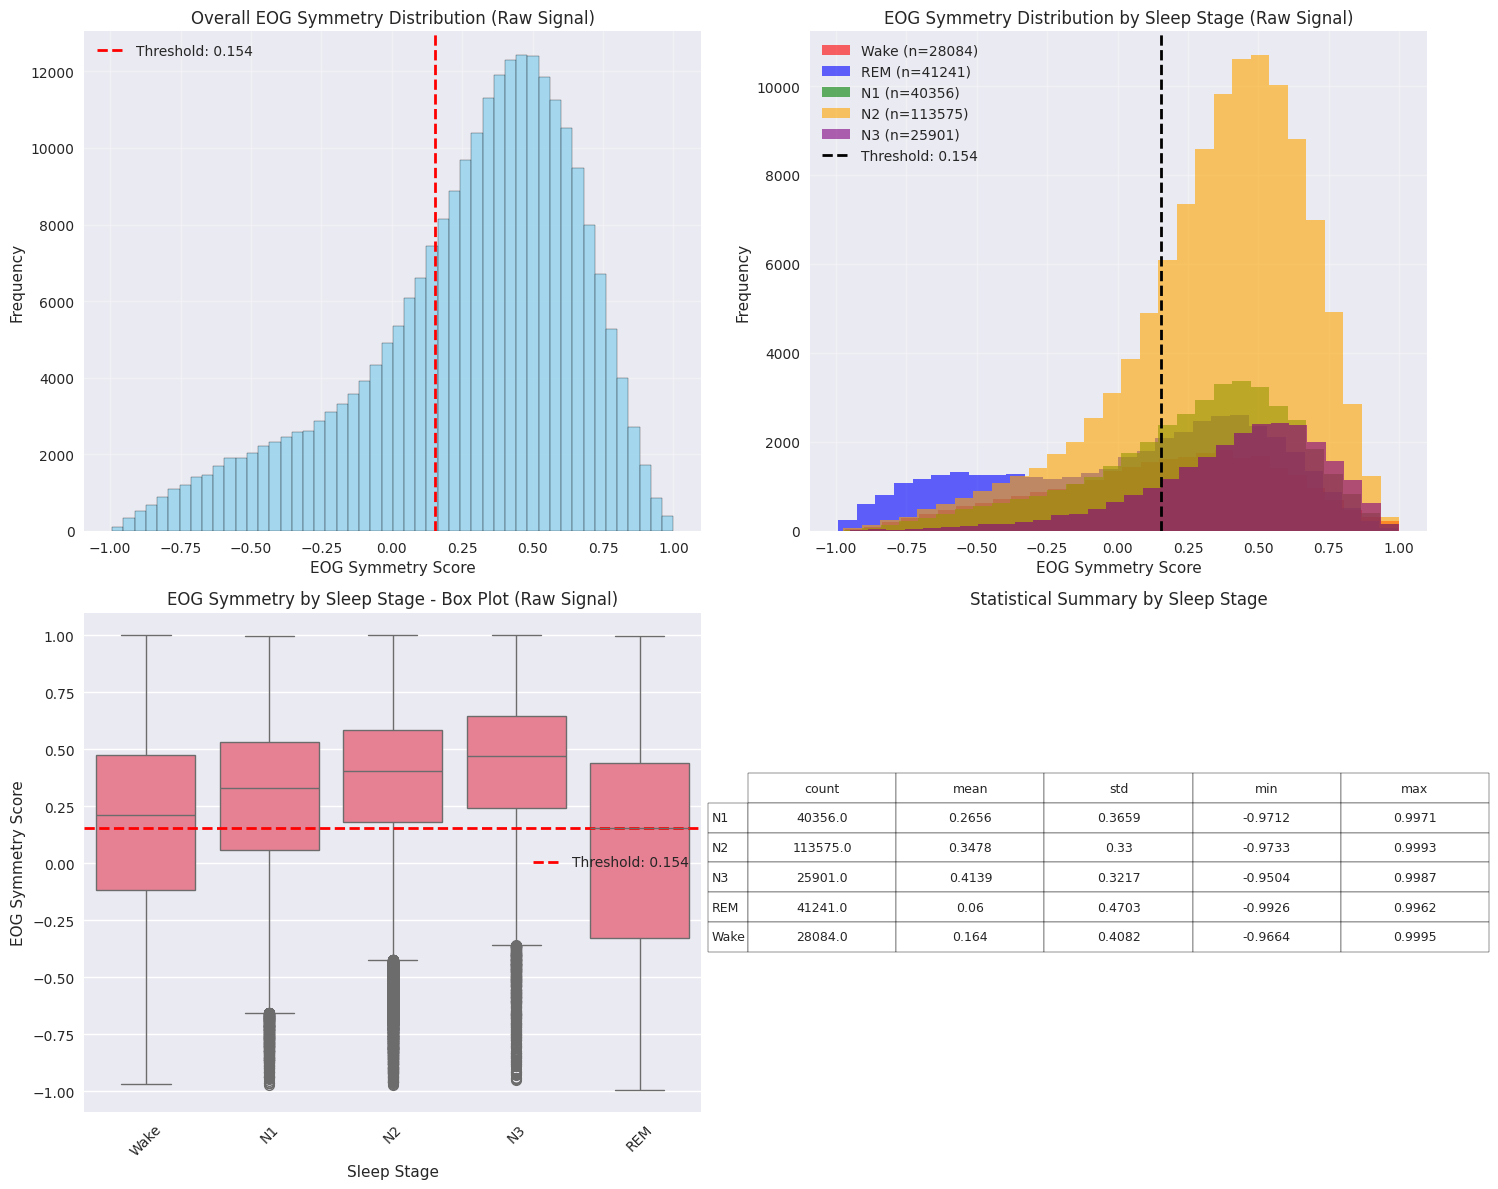


Detailed Statistics by Sleep Stage:
             count    mean     std     min     max
stage_name                                        
N1           40356  0.2656  0.3659 -0.9712  0.9971
N2          113575  0.3478  0.3300 -0.9733  0.9993
N3           25901  0.4139  0.3217 -0.9504  0.9987
REM          41241  0.0600  0.4703 -0.9926  0.9962
Wake         28084  0.1640  0.4082 -0.9664  0.9995


In [20]:
# Statistical Analysis and Visualization
if len(all_symmetry_scores) > 0:
    # Create DataFrame for analysis
    df = pd.DataFrame({
        'symmetry': all_symmetry_scores,
        'sleep_stage': all_sleep_stages,
        'stage_name': [sleep_stage_names[int(stage)] for stage in all_sleep_stages]
    })

    # Overall symmetry distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Overall symmetry histogram
    axes[0, 0].hist(all_symmetry_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[0, 0].set_xlabel('EOG Symmetry Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Overall EOG Symmetry Distribution (Raw Signal)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Symmetry distribution by sleep stage
    stage_colors = ['red', 'blue', 'green', 'orange', 'purple']
    for stage in range(5):
        stage_data = df[df['sleep_stage'] == stage]['symmetry']
        if len(stage_data) > 0:
            axes[0, 1].hist(stage_data, bins=30, alpha=0.6, 
                           label=f'{sleep_stage_names[stage]} (n={len(stage_data)})',
                           color=stage_colors[stage])

    axes[0, 1].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[0, 1].set_xlabel('EOG Symmetry Score')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('EOG Symmetry Distribution by Sleep Stage (Raw Signal)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Box plot by sleep stage
    sns.boxplot(data=df, x='stage_name', y='symmetry', ax=axes[1, 0])
    axes[1, 0].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    axes[1, 0].set_xlabel('Sleep Stage')
    axes[1, 0].set_ylabel('EOG Symmetry Score')
    axes[1, 0].set_title('EOG Symmetry by Sleep Stage - Box Plot (Raw Signal)')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    # 4. Statistical summary table
    stats_summary = df.groupby('stage_name')['symmetry'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    table = axes[1, 1].table(cellText=stats_summary.values, 
                            rowLabels=stats_summary.index,
                            colLabels=stats_summary.columns,
                            cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    axes[1, 1].set_title('Statistical Summary by Sleep Stage')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nDetailed Statistics by Sleep Stage:")
    print(stats_summary)

In [21]:
# Generate XML output for each file
print("\n" + "="*60)
print("GENERATING XML OUTPUT FOR EACH FILE")
print("="*60)

os.makedirs(output_dir, exist_ok=True)

# Group data by file
file_groups = {}
for mapping in file_data_mapping:
    file_idx = mapping['file_idx']
    if file_idx not in file_groups:
        file_groups[file_idx] = {
            'file_name': mapping['file_name'],
            'base_name': mapping['base_name'],
            'base_time': mapping['base_time'],  # Using base_time from EDF
            'epochs': []
        }
    file_groups[file_idx]['epochs'].append(mapping['local_epoch_idx'])

# Process each file
for file_idx, file_info in file_groups.items():
    file_name = file_info['file_name']
    base_name = file_info['base_name']
    base_time = file_info['base_time']  # Using base_time from EDF
    
    print(f"\nProcessing: {file_name}")
    print(f"  Base time (EDF start): {base_time}")
    
    # Collect EOG data for this file
    file_eog_data = []
    for i, mapping in enumerate(file_data_mapping):
        if mapping['file_idx'] == file_idx:
            file_eog_data.append(all_eog_data[i])
    
    if len(file_eog_data) == 0:
        continue
    
    print(f"  Number of epochs: {len(file_eog_data)}")
    
    # Create binary labels for symmetric EOG
    y_continuous = []
    
    for loc_signal, roc_signal in file_eog_data:
        # Calculate symmetry for this epoch
        symmetry_scores, window_positions = calculate_eog_symmetry(
            loc_signal, roc_signal, window_size, stride
        )
        
        # Create continuous labels (1500 samples per epoch)
        y = np.zeros(1500, dtype=np.float32)
        
        # Mark symmetric regions
        for score, pos in zip(symmetry_scores, window_positions):
            if score > threshold:
                # Mark the window region as symmetric
                end_pos = min(pos + window_size, 1500)
                y[pos:end_pos] = 1.0
        
        y_continuous.append(y)
    
    y_continuous = np.concatenate(y_continuous)
    
    # Save XML using base_time from EDF
    xml_filename = f"{base_name}_EOG_SYM.xml"
    xml_save_path = os.path.join(output_dir, xml_filename)
    
    event_count = save_symmetric_eog_xml(
        base_time=base_time,  # Using base_time from EDF
        y_all_epochs=y_continuous,
        sfreq=fs,
        xml_save_path=xml_save_path,
        description="EOG_SYMMETRIC",
        location="EOG",
        min_duration=0.5
    )
    
    print(f"  XML saved: {xml_filename}")
    print(f"  Symmetric EOG events: {event_count}")

print("\n" + "="*60)
print(f"XML files saved to: {output_dir}")
print(f"Threshold used: {threshold:.4f}")
print("="*60)


GENERATING XML OUTPUT FOR EACH FILE

Processing: SCH-230114R3_M-60-OV-SE.edf
  Base time (EDF start): 2023-01-14 20:58:49
  Number of epochs: 779
  XML saved: SCH-230114R3_M-60-OV-SE_EOG_SYM.xml
  Symmetric EOG events: 2434

Processing: SCH_F_20_OB_231128R4_NO.edf
  Base time (EDF start): 2023-11-28 22:11:30
  Number of epochs: 894
  XML saved: SCH_F_20_OB_231128R4_NO_EOG_SYM.xml
  Symmetric EOG events: 2385

Processing: SCH_F_20_OV_230715R3_MO.edf
  Base time (EDF start): 2023-07-15 22:12:17
  Number of epochs: 890
  XML saved: SCH_F_20_OV_230715R3_MO_EOG_SYM.xml
  Symmetric EOG events: 3060

Processing: SCH_F_40_NW_230511R3_SE.edf
  Base time (EDF start): 2023-05-11 22:34:32
  Number of epochs: 824
  XML saved: SCH_F_40_NW_230511R3_SE_EOG_SYM.xml
  Symmetric EOG events: 2928

Processing: SCH_F_40_NW_231130R4_MO.edf
  Base time (EDF start): 2023-11-30 22:05:57
  Number of epochs: 836
  XML saved: SCH_F_40_NW_231130R4_MO_EOG_SYM.xml
  Symmetric EOG events: 3070

XML files saved to: /h

In [22]:
# Final Summary
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY - Version 2 (Raw EDF)")
print("="*60)

print(f"\nData Loading Method:")
print(f"  - Direct EDF loading using sleep_stage modules")
print(f"  - Raw signal processing without normalization")
print(f"  - Using base_time from EDF file (not SLEEP XML)")
print(f"  - Channel mapping based on sleep_score.py")

print(f"\nDataset Information:")
print(f"  Total files processed: {len(file_groups)}")
print(f"  Total 30-second epochs: {len(all_eog_data)}")
print(f"  Total symmetry windows: {len(all_symmetry_scores)}")

if len(rem_symmetry_scores) > 0:
    print(f"\nThreshold Calculation:")
    print(f"  Based on REM stage statistics")
    print(f"  REM windows used: {len(rem_symmetry_scores)}")
    print(f"  Threshold value: {threshold:.4f}")
    print(f"  Method: {threshold_percentile}th percentile of REM symmetry scores")

# Classification results
if len(all_symmetry_scores) > 0:
    symmetric_classifications = all_symmetry_scores > threshold
    symmetric_count = np.sum(symmetric_classifications)
    symmetric_percentage = (symmetric_count / len(all_symmetry_scores)) * 100
    
    print(f"\nSymmetric EOG Detection Results:")
    print(f"  Total windows analyzed: {len(all_symmetry_scores)}")
    print(f"  Symmetric EOG detected: {symmetric_count} ({symmetric_percentage:.1f}%)")
    print(f"  Asymmetric EOG: {len(all_symmetry_scores) - symmetric_count} ({100 - symmetric_percentage:.1f}%)")
    
    # Breakdown by sleep stage
    print(f"\nSymmetric EOG by Sleep Stage:")
    for stage in range(5):
        stage_mask = all_sleep_stages == stage
        if np.any(stage_mask):
            stage_total = np.sum(stage_mask)
            stage_symmetric = np.sum(symmetric_classifications[stage_mask])
            stage_percentage = (stage_symmetric / stage_total) * 100 if stage_total > 0 else 0
            print(f"  {sleep_stage_names[stage]:>5}: {stage_symmetric:>4}/{stage_total:<4} ({stage_percentage:>5.1f}%)")

print(f"\nXML Output Summary:")
print(f"  Output directory: {output_dir}")
print(f"  XML files use base_time from EDF file directly")
print(f"  File naming: [filename]_EOG_SYM.xml")

print("\n" + "="*60)
print("Analysis completed successfully!")
print("Version 2: Using raw EDF signals without normalization")
print("Version 2: Using base_time from EDF (not SLEEP XML)")
print("="*60)


FINAL ANALYSIS SUMMARY - Version 2 (Raw EDF)

Data Loading Method:
  - Direct EDF loading using sleep_stage modules
  - Raw signal processing without normalization
  - Using base_time from EDF file (not SLEEP XML)
  - Channel mapping based on sleep_score.py

Dataset Information:
  Total files processed: 5
  Total 30-second epochs: 4223
  Total symmetry windows: 249157

Threshold Calculation:
  Based on REM stage statistics
  REM windows used: 41241
  Threshold value: 0.1542
  Method: 50th percentile of REM symmetry scores

Symmetric EOG Detection Results:
  Total windows analyzed: 249157
  Symmetric EOG detected: 171882 (69.0%)
  Asymmetric EOG: 77275 (31.0%)

Symmetric EOG by Sleep Stage:
   Wake: 15415/28084 ( 54.9%)
    REM: 20620/41241 ( 50.0%)
     N1: 27300/40356 ( 67.6%)
     N2: 87459/113575 ( 77.0%)
     N3: 21088/25901 ( 81.4%)

XML Output Summary:
  Output directory: /home/honeynaps/data/shared/integrate/output
  XML files use base_time from EDF file directly
  File naming: